# NYC Taxi — Machine Learning Analysis

**Objective:** Predict whether a ride will produce a tip (classification) and estimate the tip amount (regression).
Two models compared per task. Hyperparameter tuning via GridSearchCV. Evaluated on ROC-AUC, F1, RMSE.

## Setup

In [1]:
import io, ssl, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE = "#1d4ed8"
GRAY = "#64748b"

## Data

In [2]:
# download raw TLC data — same source as analysis notebook
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/taxis.csv"
ctx = ssl._create_unverified_context()
req = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
df_raw = pd.read_csv(io.StringIO(urllib.request.urlopen(req, context=ctx).read().decode()))
print(f"Rows: {len(df_raw):,}  |  Columns: {df_raw.shape[1]}")

Rows: 6,433  |  Columns: 14


In [3]:
# run the same cleaning pipeline as analysis.ipynb
df = df_raw.copy()
df["pickup"]  = pd.to_datetime(df["pickup"])
df["dropoff"] = pd.to_datetime(df["dropoff"])
df = df.dropna(subset=["payment"])
for col in ["pickup_zone","dropoff_zone","pickup_borough","dropoff_borough"]:
    df[col] = df[col].fillna("Unknown")
df = df[df["fare"] > 0].copy()

df["hour"]         = df["pickup"].dt.hour
df["day_name"]     = df["pickup"].dt.day_name()
df["trip_minutes"] = ((df["dropoff"] - df["pickup"]).dt.total_seconds() / 60).round(2)
df["tipped"]       = (df["tip"] > 0).astype(int)
df["fare_per_mile"]= (df["fare"] / df["distance"].replace(0, np.nan)).round(3)

p99 = df["total"].quantile(0.99)
df  = df[df["total"] <= p99].copy()
print(f"Clean rows: {len(df):,}")

Clean rows: 6,333


## Feature Engineering

In [4]:
# encode categoricals
le = LabelEncoder()
df["color_enc"]   = le.fit_transform(df["color"])
df["payment_enc"] = le.fit_transform(df["payment"])
df["borough_enc"] = le.fit_transform(df["pickup_borough"])
df["day_enc"]     = le.fit_transform(df["day_name"])

In [5]:
# all features used in every model
FEATURES = [
    "passengers", "distance", "fare", "tolls",
    "hour", "day_enc", "trip_minutes", "fare_per_mile",
    "color_enc", "payment_enc", "borough_enc"
]

df_ml = df.dropna(subset=FEATURES + ["tipped", "tip"])
print(f"Model-ready rows: {len(df_ml):,}")
print(f"Class balance — tipped: {df_ml['tipped'].mean()*100:.1f}%  |  no tip: {(1-df_ml['tipped'].mean())*100:.1f}%")

Model-ready rows: 6,291
Class balance — tipped: 64.7%  |  no tip: 35.3%


In [6]:
# train/test split — stratified to preserve class ratio
X = df_ml[FEATURES].values
y = df_ml["tipped"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 5032  |  Test: 1259


In [7]:
# scale features for logistic regression
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Classification — Predict Tip vs No Tip

### Baseline — Logistic Regression

In [8]:
# logistic regression as interpretable baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print(classification_report(y_test, y_pred_lr, target_names=["No Tip", "Tipped"]))

              precision    recall  f1-score   support

      No Tip       0.97      0.87      0.92       444
      Tipped       0.93      0.99      0.96       815

    accuracy                           0.95      1259
   macro avg       0.95      0.93      0.94      1259
weighted avg       0.95      0.95      0.94      1259



### Model 1 — Random Forest with GridSearchCV

In [9]:
# hyperparameter grid for random forest
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth":    [6, 10, None],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=cv,
                       scoring="f1", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

print(f"Best params : {rf_grid.best_params_}")
print(f"Best CV F1  : {rf_grid.best_score_:.4f}")

Best params : {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1  : 0.9660


In [10]:
# evaluate best random forest on test set
best_rf   = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["No Tip", "Tipped"]))

              precision    recall  f1-score   support

      No Tip       0.98      0.87      0.92       444
      Tipped       0.94      0.99      0.96       815

    accuracy                           0.95      1259
   macro avg       0.96      0.93      0.94      1259
weighted avg       0.95      0.95      0.95      1259



### Model 2 — XGBoost Classifier with GridSearchCV

In [11]:
# hyperparameter grid for XGBoost classifier
param_grid_xgb = {
    "n_estimators":  [100, 200],
    "max_depth":     [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

xgb_base = XGBClassifier(random_state=42, eval_metric="logloss", verbosity=0)
xgb_grid = GridSearchCV(xgb_base, param_grid_xgb, cv=cv,
                        scoring="f1", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)

print(f"Best params : {xgb_grid.best_params_}")
print(f"Best CV F1  : {xgb_grid.best_score_:.4f}")

Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1  : 0.9657


In [12]:
# evaluate best XGBoost on test set
best_xgb   = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=["No Tip", "Tipped"]))

              precision    recall  f1-score   support

      No Tip       0.98      0.87      0.92       444
      Tipped       0.93      0.99      0.96       815

    accuracy                           0.95      1259
   macro avg       0.96      0.93      0.94      1259
weighted avg       0.95      0.95      0.95      1259



### Model Comparison — Cross-Validation

In [13]:
# 5-fold CV comparison across all three classifiers
models = {
    "Logistic Regression": (lr, X_train_sc),
    "Random Forest":       (best_rf,  X_train),
    "XGBoost":             (best_xgb, X_train),
}

rows = []
for name, (model, X_tr) in models.items():
    f1_scores  = cross_val_score(model, X_tr, y_train, cv=cv, scoring="f1")
    acc_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring="accuracy")
    rows.append({
        "Model":      name,
        "CV F1 Mean": round(f1_scores.mean(), 4),
        "CV F1 Std":  round(f1_scores.std(),  4),
        "CV Acc Mean":round(acc_scores.mean(),4),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
comparison_df

,CV F1 Mean,CV F1 Std,CV Acc Mean
Model,,,
Logistic Regression,0.9636,0.0047,0.9517
Random Forest,0.9660,0.0031,0.9549
XGBoost,0.9657,0.0029,0.9545


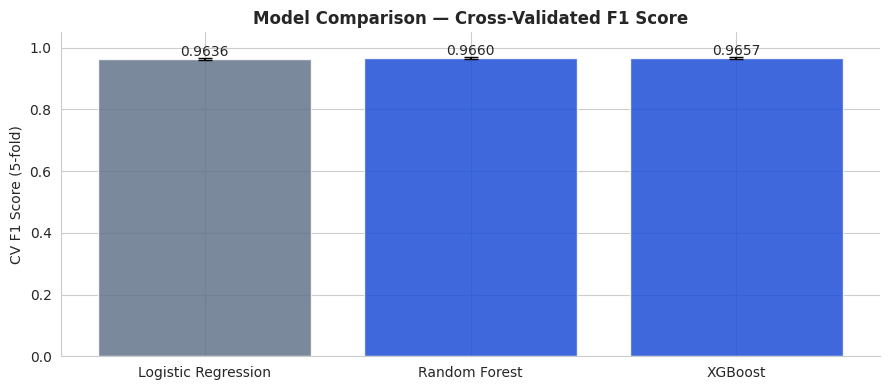

In [14]:
# bar chart comparing CV F1 scores
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(comparison_df.index, comparison_df["CV F1 Mean"],
              color=[GRAY, BLUE, BLUE], alpha=0.85,
              yerr=comparison_df["CV F1 Std"], capsize=5)
ax.set_ylabel("CV F1 Score (5-fold)")
ax.set_title("Model Comparison — Cross-Validated F1 Score")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, comparison_df["CV F1 Mean"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Confusion Matrices — RF vs XGBoost

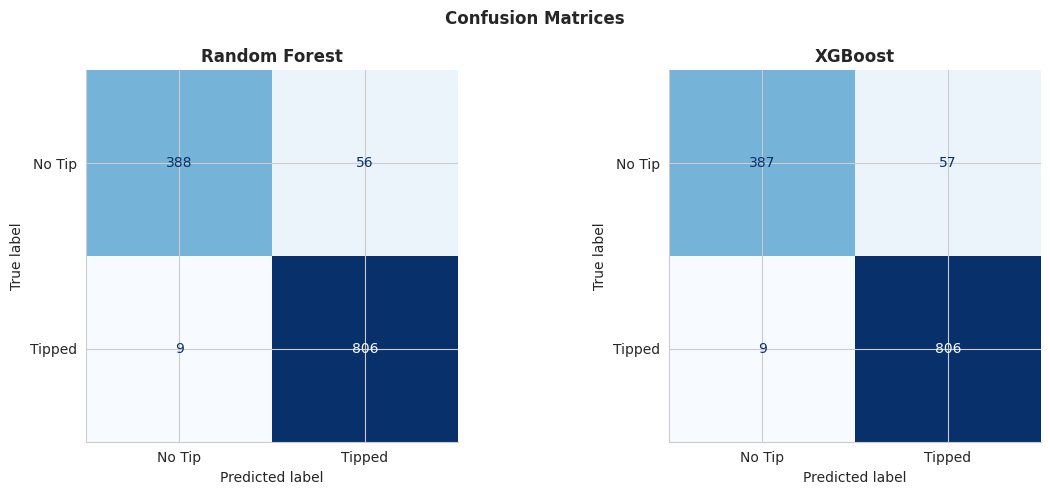

In [15]:
# side-by-side confusion matrices for the two best models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_p, title in zip(axes,
    [y_pred_rf, y_pred_xgb],
    ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["No Tip","Tipped"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.suptitle("Confusion Matrices", fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# breakdown of confusion matrix for the best model (XGBoost)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm_xgb.ravel()
precision = tp / (tp + fp)
recall    = tp / (tp + fn)

print(f"True  Positives : {tp:>5}  (correctly predicted Tipped)")
print(f"False Positives : {fp:>5}  (predicted Tipped, was No Tip)")
print(f"True  Negatives : {tn:>5}  (correctly predicted No Tip)")
print(f"False Negatives : {fn:>5}  (missed a tipped ride)")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")

True  Positives :   806  (correctly predicted Tipped)
False Positives :    57  (predicted Tipped, was No Tip)
True  Negatives :   387  (correctly predicted No Tip)
False Negatives :     9  (missed a tipped ride)
Precision       : 0.9340
Recall          : 0.9890


### ROC Curve

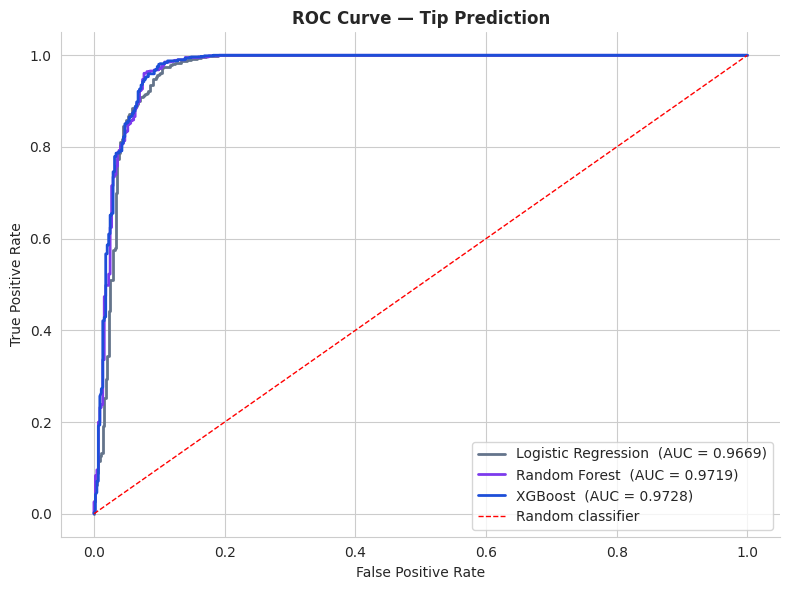

In [17]:
# ROC curves for all three classifiers
fig, ax = plt.subplots(figsize=(8, 6))

roc_models = {
    "Logistic Regression": (lr, X_test_sc),
    "Random Forest":       (best_rf,  X_test),
    "XGBoost":             (best_xgb, X_test),
}
colors_roc = [GRAY, "#7c3aed", BLUE]

for (name, (model, X_te)), color in zip(roc_models.items(), colors_roc):
    y_prob      = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {roc_auc:.4f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="red", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Tip Prediction")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Feature Importance

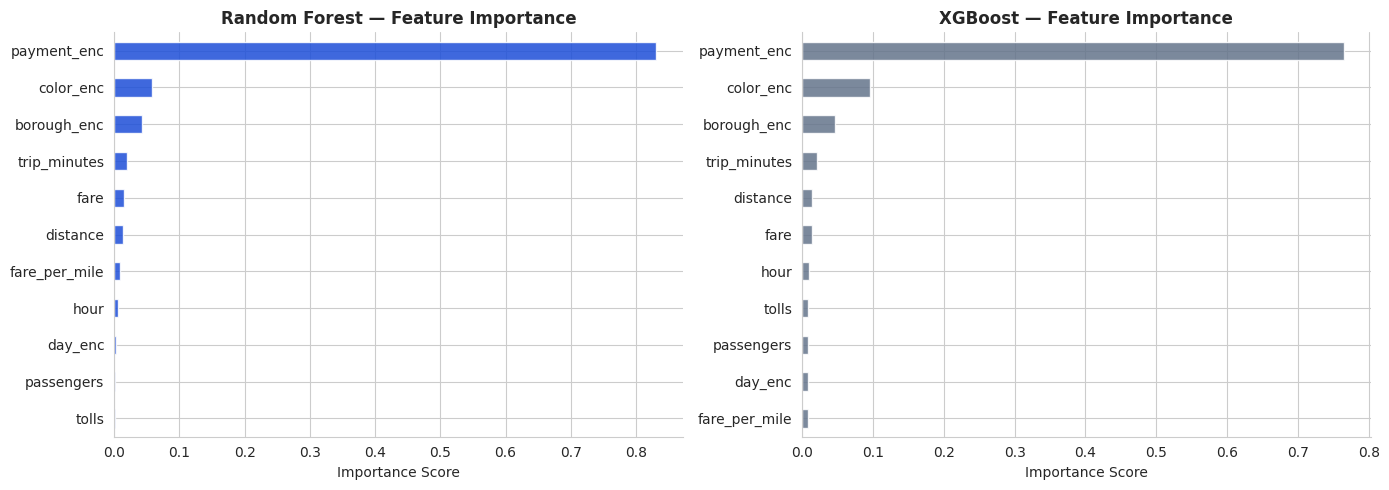

In [18]:
# feature importance from random forest and XGBoost side by side
fi_rf  = pd.Series(best_rf.feature_importances_,  index=FEATURES).sort_values()
fi_xgb = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_rf.plot.barh(ax=axes[0], color=BLUE, alpha=0.85)
axes[0].set_title("Random Forest — Feature Importance")
axes[0].set_xlabel("Importance Score")

fi_xgb.plot.barh(ax=axes[1], color=GRAY, alpha=0.85)
axes[1].set_title("XGBoost — Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

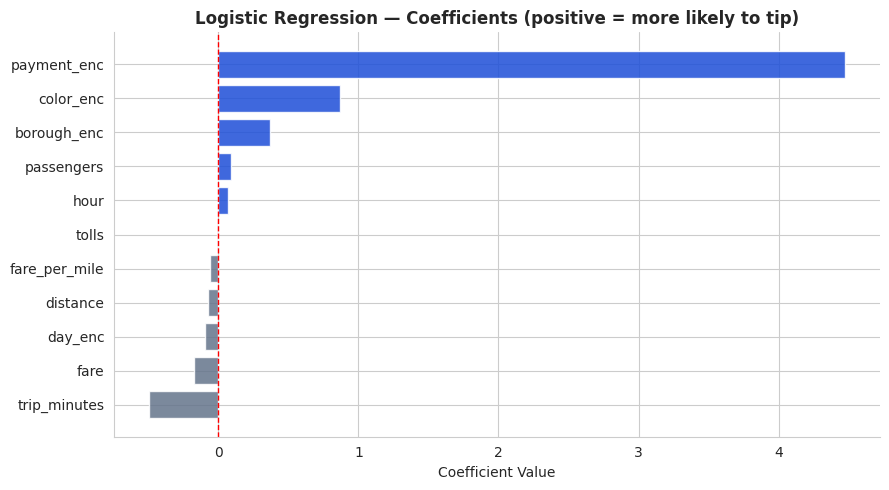

In [19]:
# logistic regression coefficients — shows direction of effect
feat_names = FEATURES
coef_df = pd.DataFrame({
    "feature":     feat_names,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors_lr = [BLUE if c > 0 else GRAY for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors_lr, alpha=0.85)
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_title("Logistic Regression — Coefficients (positive = more likely to tip)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

## Regression — Predict Tip Amount (Tipped Rides Only)

In [20]:
# restrict to rides that produced a tip
df_tipped = df_ml[df_ml["tipped"] == 1].copy()
X_r = df_tipped[FEATURES].values
y_r = df_tipped["tip"].values

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
print(f"Tipped rides — train: {len(X_tr_r)}  |  test: {len(X_te_r)}")
print(f"Tip range in test: ${y_te_r.min():.2f} – ${y_te_r.max():.2f}")

Tipped rides — train: 3258  |  test: 815
Tip range in test: $0.06 – $14.12


### Model 1 — Random Forest Regressor

In [21]:
# random forest regression with grid search
from sklearn.ensemble import RandomForestRegressor

rf_reg_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {"n_estimators": [100, 200], "max_depth": [6, 10, None]},
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
rf_reg_grid.fit(X_tr_r, y_tr_r)
print(f"Best params : {rf_reg_grid.best_params_}")

Best params : {'max_depth': 6, 'n_estimators': 200}


In [22]:
# evaluate RF regressor
best_rf_reg  = rf_reg_grid.best_estimator_
preds_rf_reg = best_rf_reg.predict(X_te_r)

rmse_rf = np.sqrt(mean_squared_error(y_te_r, preds_rf_reg))
mae_rf  = mean_absolute_error(y_te_r, preds_rf_reg)
r2_rf   = r2_score(y_te_r, preds_rf_reg)
print(f"Random Forest Regressor — RMSE: ${rmse_rf:.3f}  |  MAE: ${mae_rf:.3f}  |  R2: {r2_rf:.4f}")

Random Forest Regressor — RMSE: $1.057  |  MAE: $0.657  |  R2: 0.7519


### Model 2 — XGBoost Regressor

In [23]:
# XGBoost regression with grid search
xgb_reg_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {"n_estimators": [200, 300], "max_depth": [4, 6], "learning_rate": [0.05, 0.1]},
    cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1
)
xgb_reg_grid.fit(X_tr_r, y_tr_r)
print(f"Best params : {xgb_reg_grid.best_params_}")

Best params : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}


In [24]:
# evaluate XGBoost regressor
best_xgb_reg  = xgb_reg_grid.best_estimator_
preds_xgb_reg = best_xgb_reg.predict(X_te_r)

rmse_xgb = np.sqrt(mean_squared_error(y_te_r, preds_xgb_reg))
mae_xgb  = mean_absolute_error(y_te_r, preds_xgb_reg)
r2_xgb   = r2_score(y_te_r, preds_xgb_reg)
print(f"XGBoost Regressor      — RMSE: ${rmse_xgb:.3f}  |  MAE: ${mae_xgb:.3f}  |  R2: {r2_xgb:.4f}")

XGBoost Regressor      — RMSE: $1.087  |  MAE: $0.662  |  R2: 0.7375


### Regression Model Comparison

In [25]:
# side-by-side regression metric comparison
reg_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE":  [round(rmse_rf, 4), round(rmse_xgb, 4)],
    "MAE":   [round(mae_rf,  4), round(mae_xgb,  4)],
    "R2":    [round(r2_rf,   4), round(r2_xgb,   4)],
}).set_index("Model")
reg_comparison

,RMSE,MAE,R2
Model,,,
Random Forest,1.0569,0.6566,0.7519
XGBoost,1.0869,0.6615,0.7375


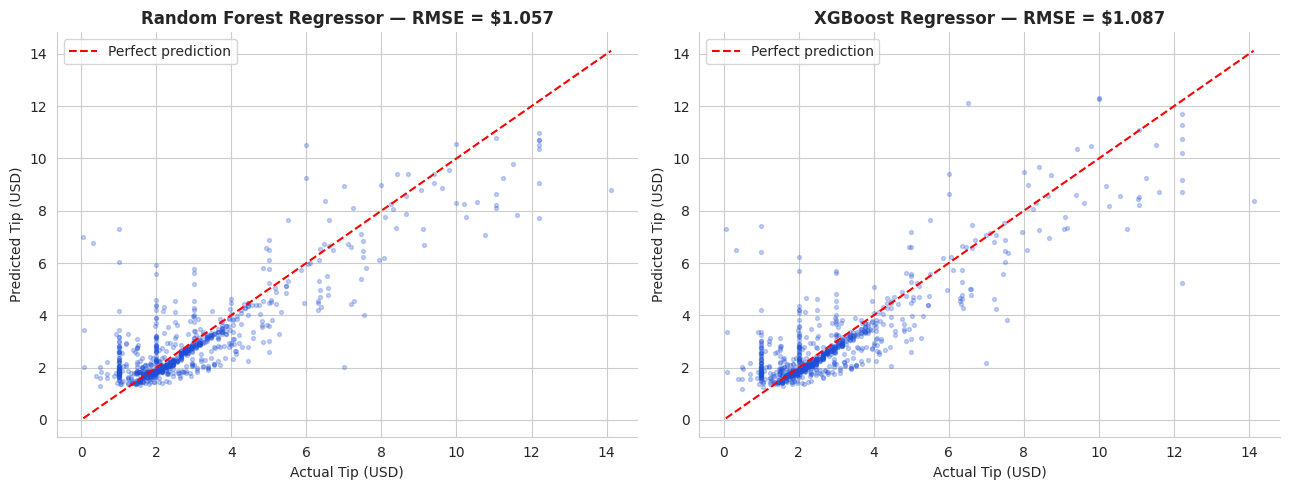

In [26]:
# actual vs predicted scatter for both regression models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title, rmse in zip(
    axes,
    [preds_rf_reg, preds_xgb_reg],
    ["Random Forest Regressor", "XGBoost Regressor"],
    [rmse_rf, rmse_xgb]
):
    ax.scatter(y_te_r, preds, alpha=0.25, s=8, color=BLUE)
    lims = [min(y_te_r.min(), preds.min()), max(y_te_r.max(), preds.max())]
    ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--", label="Perfect prediction")
    ax.set_xlabel("Actual Tip (USD)")
    ax.set_ylabel("Predicted Tip (USD)")
    ax.set_title(f"{title} — RMSE = ${rmse:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

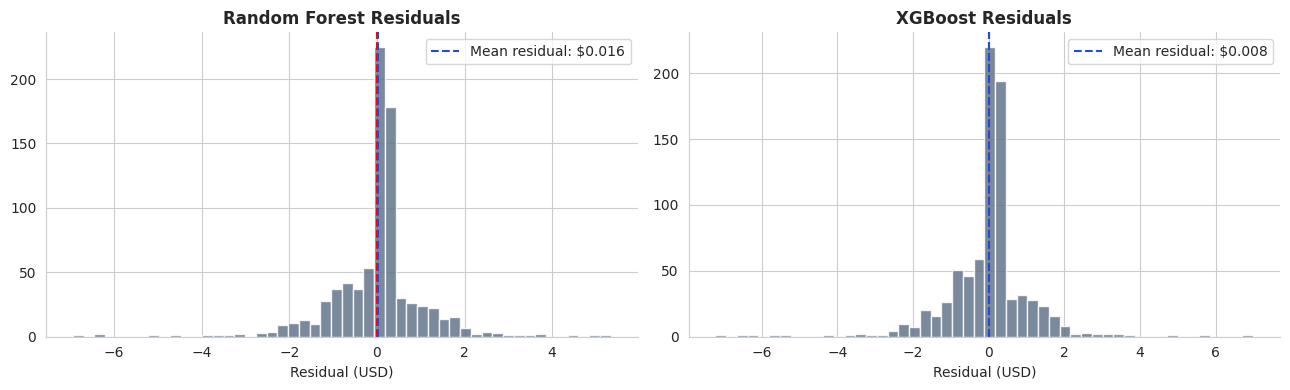

In [27]:
# residual distributions for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, preds, title in zip(
    axes,
    [preds_rf_reg, preds_xgb_reg],
    ["Random Forest Residuals", "XGBoost Residuals"]
):
    residuals = y_te_r - preds
    ax.hist(residuals, bins=50, color=GRAY, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.5, linestyle="--")
    ax.axvline(residuals.mean(), color=BLUE, linewidth=1.5, linestyle="--",
               label=f"Mean residual: ${residuals.mean():.3f}")
    ax.set_xlabel("Residual (USD)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## Summary

In [28]:
# final model performance table
summary = pd.DataFrame({
    "Task":    ["Classification","Classification","Classification",
                "Regression","Regression"],
    "Model":   ["Logistic Regression","Random Forest","XGBoost",
                "Random Forest","XGBoost"],
    "Metric":  ["F1 (weighted)","F1 (weighted)","F1 (weighted)",
                "RMSE","RMSE"],
    "Score":   [
        round(float(pd.DataFrame(
            classification_report(y_test, y_pred_lr, output_dict=True)
        ).T.loc["weighted avg","f1-score"]), 4),
        round(float(pd.DataFrame(
            classification_report(y_test, y_pred_rf, output_dict=True)
        ).T.loc["weighted avg","f1-score"]), 4),
        round(float(pd.DataFrame(
            classification_report(y_test, y_pred_xgb, output_dict=True)
        ).T.loc["weighted avg","f1-score"]), 4),
        round(rmse_rf, 4),
        round(rmse_xgb, 4),
    ]
})
summary

,Task,Model,Metric,Score
0,Classification,Logistic Regression,F1 (weighted),0.9444
1,Classification,Random Forest,F1 (weighted),0.9477
2,Classification,XGBoost,F1 (weighted),0.9468
3,Regression,Random Forest,RMSE,1.0569
4,Regression,XGBoost,RMSE,1.0869
